<a href="https://colab.research.google.com/github/leeno-ob/IT326-project/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **1-Problem**




The problem addressed in this project is analyzing students’ academic performance based on their exam scores.  Understanding student performance is important as it helps identify students who may need additional academic support as well as those who are performing well. This project aims to classify students based on their performance levels and group them into clusters with similar characteristics. It also seeks to understand which factors influence student performance. Solving this problem helps educators provide better academic support and enables institutions to make more informed educational decisions.


# **2-Data Mining Task**
The data mining tasks in this project included both classification and clustering techniques.



## *1. Classification Task*



The goal of the classification task is to predict students’ academic performance based on their exam scores and related features. This allows us to understand the factors that affect student performance and to classify them into  suitable performance categories.

## *2. Clustering Task*

The clustering task aims to group students into natural clusters based on similarities in their exam scores and study-related features. This is useful for discovering hidden patterns, identifying groups of students with similar performance characteristics, and assisting educators in designing targeted academic support strategies.



## *Overall Task Definition*


By combining supervised learning (classification) and unsupervised learning (clustering), the project aims to predict student performance while uncovering meaningful patterns in the dataset, enhancing the understanding of students’ academic behavior.

# **3-Data**


## *Dataset Description*





6607 records, 20 attributes

Data type includes numerical and categorical features

Target variable = Exam_Score



**Class Label Description:**


Low: Low exam performance

Medium: Average exam performance

High: High exam performance

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/leeno-ob/IT326-project/refs/heads/main/Dataset/Raw_dataset.csv"

df = pd.read_csv(url)

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nDataset Description:")
print(f"Number of records: {df.shape[0]}")
print(f"Number of attributes: {df.shape[1]}")

print("\nTarget variable = Exam_Score")

print("\nClass Label Description:")
print("Low: Low exam performance")
print("Moderate: Average exam performance")
print("High: High exam performance")

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 

## *Loading the dataset and Import libraries:*

In [ ]:
# read Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/leeno-ob/IT326-project/refs/heads/main/Dataset/Raw_dataset.csv"
data = pd.read_csv(url)
df = pd.DataFrame(data)
df_copy = df.copy()

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



## *Class label*



The target variable in this project is **Performance_Level**, which represents students’ academic performance. It is divided into three classes:

 **Low**: Students with low exam scores and weak academic performance.  

 **Medium**: Students with average exam scores and moderate performance.  

 **High**: Students with high exam scores and strong academic performance.  

Based on the dataset distribution:

Medium: 53.4%  

 High: 24.6%  

 Low: 22.0%  

The distribution shows that the dataset is slightly imbalanced, with the majority of students belonging to the Medium class. This may influence the model, as it can become more biased toward predicting the dominant class.

The pie chart above illustrates the proportion of each class, providing a clear understanding of how the data is distributed.

Performance_Level
Medium    53.4
High      24.6
Low       22.0
Name: proportion, dtype: float64


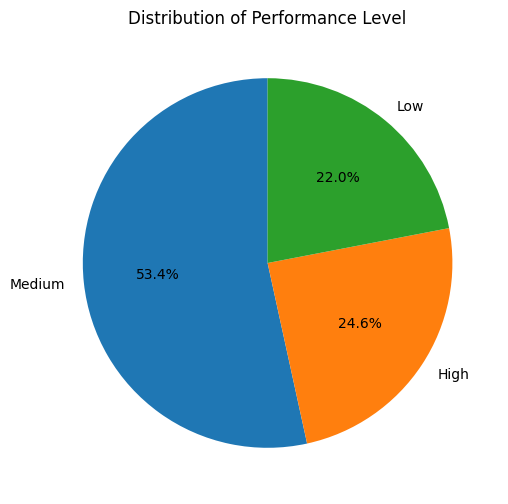

In [ ]:
import matplotlib.pyplot as plt


def performance_level(score):
    if score <= 64:
        return "Low"
    elif score <= 69:
        return "Medium"
    else:
        return "High"

data["Performance_Level"] = data["Exam_Score"].apply(performance_level)

counts = data["Performance_Level"].value_counts()
percentages = data["Performance_Level"].value_counts(normalize=True) * 100

print(percentages.round(1))


counts.plot.pie(autopct='%1.1f%%', figsize=(6,6), startangle=90)
plt.title("Distribution of Performance Level")
plt.ylabel("")
plt.show()

## *Summary*

The dataset contains 6607 records and 20 attributes.

The target variable is Exam_Score, which was converted into three classes: Low, Medium, High.

This dataset description provides the foundation for building machine learning models in the next phases.

#**4-Data Preprocessing**


##*Snapshot before preprocessing*

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/leeno-ob/IT326-project/refs/heads/main/Dataset/Raw_dataset.csv"
df = pd.read_csv(url)

df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


Before preprocessing, the dataset contained raw values with both numerical and categorical attributes. Many features were in textual format such as Yes/No and Low/Medium/High, which are not suitable for machine learning models.

In addition, some attributes contained missing values, and numerical features had different scales. These issues made preprocessing necessary before applying any data mining techniques.

## *Data Preprocessing tasks*


Several preprocessing tasks were applied to improve the dataset quality and prepare it for analysis.



###*Handling Missing Values*


In [ ]:
df_preprocessed = df.copy()

In [ ]:
cat_missing_cols = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

for col in cat_missing_cols:
    mode_value = df_preprocessed[col].mode()[0]
    print(f"Mode used for {col}: {mode_value}")
    df_preprocessed[col] = df_preprocessed[col].fillna(mode_value)

Mode used for Teacher_Quality: 1
Mode used for Parental_Education_Level: 0
Mode used for Distance_from_Home: 0


* **Why**:

    Missing values can negatively affect model performance and lead to inaccurate results.
* **How**:

    Missing values were replaced using the most frequent value (mode).
* **Attributes**:

    Teacher_Quality, Parental_Education_Level, Distance_from_Home
* **Results**:

    All missing values were handled, and the dataset became complete.


###*Noise Removal*




In [ ]:
invalid_scores = df_preprocessed[
    (df_preprocessed["Exam_Score"] < 0) |
    (df_preprocessed["Exam_Score"] > 100)
]

invalid_scores[["Exam_Score"]]


df_preprocessed = df_preprocessed[
    (df_preprocessed["Exam_Score"] >= 0) &
    (df_preprocessed["Exam_Score"] <= 100)
]

invalid_scores_after = df_preprocessed[
    (df_preprocessed["Exam_Score"] < 0) |
    (df_preprocessed["Exam_Score"] > 100)
]

print("Invalid scores after Noise removal:", len(invalid_scores_after))


Invalid scores after Noise removal: 0


* **Why**:

    Invalid values such as exam scores outside the valid range can affect data accuracy.

* **How**:

    Values outside the valid range (0–100) were removed.

* **Attributes**:

    Exam_Score

* **Results**:

    All invalid values were removed, improving data reliability.


###*Discretization*





Performance_Level
Low       1452
Medium    3530
High      1624
Name: count, dtype: int64


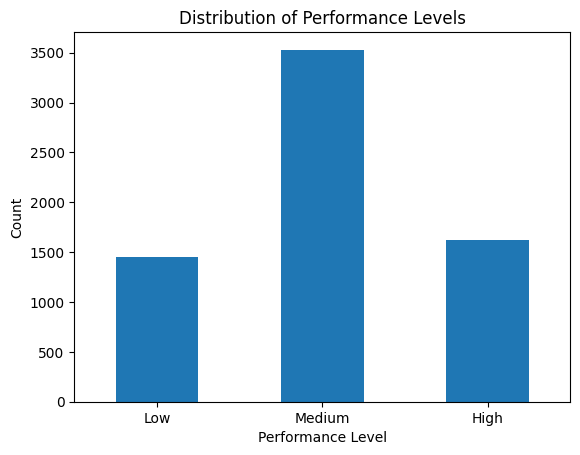

In [ ]:
import matplotlib.pyplot as plt

def categorize(score):
    if score <= 64:
        return "Low"
    elif score <= 69:
        return "Medium"
    else:
        return "High"

df_preprocessed["Performance_Level"] = df_preprocessed["Exam_Score"].apply(categorize)

order = ["Low", "Medium", "High"]
counts = df_preprocessed["Performance_Level"].value_counts().reindex(order)

print(counts)

counts.plot(kind="bar")

plt.title("Distribution of Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

* **Why**:

    To simplify numerical values into categories and support classification tasks.
* **How**:

    Exam_Score was converted into three categories: Low, Medium, and High.
* **Attributes**:

    Exam_Score → Performance_Level
* **Results**:

    A new categorical feature (Performance_Level) was created.

###*Encoding*


In [ ]:

cols_to_normalize = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Teacher_Quality",
    "Family_Income",
    "Distance_from_Home",
    "Internet_Access",
    "Extracurricular_Activities",
    "Learning_Disabilities",
    "Peer_Influence",
    "Parental_Education_Level",
    "Gender",
    "School_Type"
]

for col in cols_to_normalize:
    if col in df_preprocessed.columns:
        df_preprocessed[col] = (
            df_preprocessed[col]
            .astype("string")
            .str.strip()
            .str.lower()
        )

ordinal_mapping = {
    "low": 0, "medium": 1, "high": 2,
    "near": 0, "moderate": 1, "far": 2
}

yes_no_mapping = {"yes": 1, "no": 0}
peer_mapping = {"negative": 0, "neutral": 1, "positive": 2}
edu_mapping = {"high school": 0, "college": 1, "postgraduate": 2}
gender_mapping = {"male": 0, "female": 1}
school_mapping = {"public": 1, "private": 0}

ordinal_columns = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Teacher_Quality",
    "Family_Income",
    "Distance_from_Home"
]

yes_no_columns = [
    "Internet_Access",
    "Extracurricular_Activities",
    "Learning_Disabilities"
]

for col in ordinal_columns:
    if col in df_preprocessed.columns:
        df_preprocessed[col] = df_preprocessed[col].map(ordinal_mapping)

for col in yes_no_columns:
    if col in df_preprocessed.columns:
        df_preprocessed[col] = df_preprocessed[col].map(yes_no_mapping)

if "Peer_Influence" in df_preprocessed.columns:
    df_preprocessed["Peer_Influence"] = df_preprocessed["Peer_Influence"].map(peer_mapping)

if "Parental_Education_Level" in df_preprocessed.columns:
    df_preprocessed["Parental_Education_Level"] = df_preprocessed["Parental_Education_Level"].map(edu_mapping)

if "Gender" in df_preprocessed.columns:
    df_preprocessed["Gender"] = df_preprocessed["Gender"].map(gender_mapping)

if "School_Type" in df_preprocessed.columns:
    df_preprocessed["School_Type"] = df_preprocessed["School_Type"].map(school_mapping)

df_preprocessed = df_preprocessed.drop(
    columns=["Gender_Male", "School_Type_Public"],
    errors="ignore"
)

for col in df_preprocessed.columns:
    if df_preprocessed[col].isnull().any():
        mode_val = df_preprocessed[col].mode().iloc[0]
        df_preprocessed[col] = df_preprocessed[col].fillna(mode_val)

print(df_preprocessed.head())
print(df_preprocessed.dtypes)

   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     0                    2   
1             19          64                     0                    1   
2             24          98                     1                    1   
3             29          89                     0                    1   
4             19          92                     1                    1   

   Extracurricular_Activities  Sleep_Hours  Previous_Scores  Motivation_Level  \
0                           0            7               73                 0   
1                           0            8               59                 0   
2                           1            7               91                 1   
3                           1            8               98                 1   
4                           1            6               65                 1   

   Internet_Access  Tutoring_Sessions  ...  Teacher_Quality  S


* **Why**:

    Machine learning models require numerical input.
* **How**:

    Categorical values were converted into numerical values using encoding.
* **Attributes**:

    All categorical attributes
* **Results**:

    All categorical features were transformed into numerical format.



###*Normalization*



####*Normalization* before

In [ ]:
continuous_cols = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
]

print("Before Normalization (Min / Max):\n")
for col in continuous_cols:
    print(col, "Min:", df_preprocessed[col].min(), "Max:", df_preprocessed[col].max())

display(df_preprocessed[continuous_cols].head())

Before Normalization (Min / Max):

Hours_Studied Min: 1 Max: 44
Attendance Min: 60 Max: 100
Sleep_Hours Min: 4 Max: 10
Previous_Scores Min: 50 Max: 100


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores
0,23,84,7,73
1,19,64,8,59
2,24,98,7,91
3,29,89,8,98
4,19,92,6,65


####*Normalization* *after*

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_preprocessed[continuous_cols] = scaler.fit_transform(df_preprocessed[continuous_cols])

print(df_preprocessed[continuous_cols].head())

   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores
0       0.511628       0.600     0.500000             0.46
1       0.418605       0.100     0.666667             0.18
2       0.534884       0.950     0.500000             0.82
3       0.651163       0.725     0.666667             0.96
4       0.418605       0.800     0.333333             0.30


* **Why**:

    Different feature scales can affect model performance.
* **How**:

    Min-Max normalization was applied to scale values between 0 and 1.
* **Attributes**:

    Hours_Studied, Attendance, Sleep_Hours, Previous_Scores
* **Results**:

    All numerical features were scaled to the same range.



###*Removing Attributes*



In [ ]:
df_preprocessed = df_preprocessed.drop(columns=["Exam_Score"])

print("Columns after removing Exam_Score:")
print(df_preprocessed.columns)

Columns after removing Exam_Score:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Performance_Level'],
      dtype='object')


* **Why**:

    To avoid redundancy in the dataset.
* **How**:

    The Exam_Score attribute was removed after creating Performance_Level.
* **Attributes**:

    Exam_Score
* **Results**:

    The dataset became simpler and free from redundant information.



###*Feature Selection*


In [ ]:
from sklearn.feature_selection import VarianceThreshold

threshold_value = 0.01
target_col = "Performance_Level"

y = df_preprocessed[target_col]
X = df_preprocessed.drop(columns=[target_col], errors="ignore")

X_num = X.select_dtypes(include="number")

selector = VarianceThreshold(threshold=threshold_value)
X_selected = selector.fit_transform(X_num)

removed_cols = X_num.columns[~selector.get_support()]

print(f"Threshold: {threshold_value}")
print(f"Number of features removed: {len(removed_cols)}")

selected_cols = X_num.columns[selector.get_support()]
df_selected = pd.DataFrame(X_selected, columns=selected_cols, index=df_preprocessed.index)
df_selected[target_col] = y




Threshold: 0.01
Number of features removed: 0



* **Why**:

    To remove features with low importance.
* **How**:

    Variance Threshold was applied to detect low-variance features.
* **Attributes**:

    All numerical attributes
* **Results**:

    No features were removed, indicating all features are useful

##*Snapshot After preprocessing*

In [ ]:
df_after = pd.read_csv("https://raw.githubusercontent.com/leeno-ob/IT326-project/main/Dataset/Preprocessed_dataset.csv")
df_after.head(10)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance_Level
0,0.511628,0.600,0,2,0,0.500000,0.46,0,1,0,0,1,1,2,3,0,0,0,0,Medium
1,0.418605,0.100,0,1,0,0.666667,0.18,0,1,2,1,1,1,0,4,0,1,1,1,Low
2,0.534884,0.950,1,1,1,0.500000,0.82,1,1,2,1,1,1,1,4,0,2,0,0,High
3,0.651163,0.725,0,1,1,0.666667,0.96,1,1,1,1,1,1,0,4,0,0,1,0,High
4,0.418605,0.800,1,1,1,0.333333,0.30,1,1,3,1,2,1,1,4,0,1,0,1,High
5,0.418605,0.700,1,1,1,0.666667,0.78,1,1,3,1,1,1,2,3,0,2,0,0,High
6,0.651163,0.600,1,0,1,0.500000,0.36,0,1,1,0,1,0,1,2,0,0,1,0,Medium
7,0.558140,0.450,0,2,1,0.333333,0.00,1,1,1,2,2,1,0,2,0,0,2,0,Medium
8,0.372093,0.850,1,2,0,0.333333,0.60,2,1,0,1,0,0,1,1,0,1,0,0,Medium
9,0.511628,0.950,1,1,1,0.666667,0.42,1,1,0,2,2,1,2,5,0,0,1,0,High


After preprocessing, the dataset became clean and consistent. Missing values were handled, noise was removed, categorical features were encoded, numerical features were normalized, and redundant attributes were removed.

The Performance_Level attribute remains categorical (Low, Medium, High) at this stage and will be encoded later during the classification phase.

The dataset is now fully prepared and suitable for applying data mining techniques such as classification and clustering.


##*Save* *Dataset*

In [ ]:
df_preprocessed.to_csv("Preprocessed_dataset.csv", index=False)
#save the preprosessed data


# **5-Data Mining Technique**


This project applies two main data mining techniques: **classification** and **clustering**. These techniques were selected to analyze students’ academic performance based on their exam scores and attributes, and to achieve the project goal of predicting performance levels and grouping similar students.

Classification is used to predict student performance levels (Low, Moderate, High), while clustering is used to identify groups of students with similar patterns in their data.

## *Classification Technique*





* **Why Classification?**

Classification was used because the target variable (Performance_Level) is categorical. The goal is to predict student performance and identify students who may need academic support.


* **How Classification Was Applied**


For the classification task, the Decision Tree algorithm was applied. This algorithm was selected because it is suitable for classification problems, easy to understand, and allows interpretation of how the prediction is made based on the dataset features.

The dataset was divided into input features (X) and the target class (y), where the target variable was Performance_Level. After that, the data was split into training and testing sets using different partition sizes in order to evaluate the model under different conditions.




The **Decision Tree** algorithm was used for classification.

The following Python packages and methods were applied:

### **Classification — Packages & Methods**

| Package | Methods Used |
|---------|--------------|
| pandas | read_csv(), head() |
| sklearn.model_selection | train_test_split() |
| sklearn.tree | DecisionTreeClassifier() |
| sklearn.tree | fit(), predict() |
| sklearn.metrics | accuracy_score(), confusion_matrix()|


Two criteria were tested:

- criterion="gini"

- criterion="entropy"

The dataset was divided into different training and testing partitions:

- 90% training – 10% testing

- 80% training – 20% testing

- 70% training – 30% testing


**Why Decision Tree?**

Decision Trees are easy to interpret and suitable for this dataset. They help in understanding which features influence student performance and allow visualization of the decision process.

##*Clustering Technique*



Clustering is used to group students with similar academic performance without using predefined labels.

* **Why Clustering?**

Clustering was used to group students with similar academic performance without using labels. This helps identify hidden patterns among students.

* **How Clustering Was Applied**

For the clustering task, the **K-Means** algorithm was used. This algorithm was selected because it is one of the most common and suitable clustering methods for grouping similar records into clusters.

Before applying K-Means, data normalization was performed using StandardScaler().

The following Python packages and methods were used:

### **Clustering — Packages & Methods**

| Package | Methods Used |
|---------|--------------|
| pandas | read_csv(), head() |
| sklearn.preprocessing | StandardScaler(), fit_transform() |
| sklearn.cluster | KMeans(), fit_predict() |
| sklearn.metrics | silhouette_score() |
| KMeans attribute | inertia_ |

Different values of **K** were tested:

- K = 2

- K = 3

- K = 4

- K = 5

**How K was selected**

The optimal number of clusters was determined using:
Elbow Method (WCSS) to measure cluster compactness
Silhoutte Score to evaluate cluster quality.
These methods help select the K that produces well-separated and meaningful
clusters.

##**6-Evaluation and Comparison**

##*Classification*

In this phase, classification is performed using the Decision Tree algorithm.  
The goal is to predict the class label based on the input features.  

The Decision Tree model is applied using two splitting criteria:
- Gini Index  
- Entropy  

Different train-test splits are used to evaluate the model performance, including:
- 90% training and 10% testing  
- 80% training and 20% testing  
- 70% training and 30% testing  

The performance is evaluated using accuracy and confusion matrix.  

Finally, a comparison is conducted between the Gini Index and Entropy  across different data splits to determine the best-performing approach.

### *Import required libraries*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

### *Load the Preprocessed Dataset*

In [ ]:
classification_data = pd.read_csv("https://raw.githubusercontent.com/leeno-ob/IT326-project/main/Dataset/Preprocessed_dataset.csv")
classification_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance_Level
0,0.511628,0.600,0,2,0,0.500000,0.46,0,1,0,0,1,1,2,3,0,0,0,0,Medium
1,0.418605,0.100,0,1,0,0.666667,0.18,0,1,2,1,1,1,0,4,0,1,1,1,Low
2,0.534884,0.950,1,1,1,0.500000,0.82,1,1,2,1,1,1,1,4,0,2,0,0,High
3,0.651163,0.725,0,1,1,0.666667,0.96,1,1,1,1,1,1,0,4,0,0,1,0,High
4,0.418605,0.800,1,1,1,0.333333,0.30,1,1,3,1,2,1,1,4,0,1,0,1,High


### *Define Features and Target*
he dataset is divided into input features (X) and the class label (y).

In [ ]:
X = classification_data.drop("Performance_Level", axis=1)
y = classification_data["Performance_Level"]

###*Gini 90/10 Split*

The dataset is split into 90% training and 10% testing.  
The model is trained using the Gini index and evaluated using accuracy and confusion matrix.  

The objective is to assess the model performance and its ability to correctly predict the class label.

In [ ]:
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.10, random_state=42
)

gini_model_90 = DecisionTreeClassifier(criterion="gini", random_state=42)
gini_model_90.fit(X_train_90, y_train_90)

y_pred_90 = gini_model_90.predict(X_test_10)

accuracy_90 = accuracy_score(y_test_10, y_pred_90)
cm_90 = confusion_matrix(y_test_10, y_pred_90)

print("Accuracy (90/10):", accuracy_90)
print("Confusion Matrix:\n", cm_90)

Accuracy (90/10): 0.7655068078668684
Confusion Matrix:
 [[113   1  39]
 [  3 105  31]
 [ 34  47 288]]


The model achieved an accuracy of 76.55%, indicating good overall performance.  

The confusion matrix shows that most predictions are correct, but there are still some incorrect predictions between certain classes.  

This suggests that the model sometimes struggles to clearly distinguish between similar classes.

#### *Confusion Matrix 90/10 split*



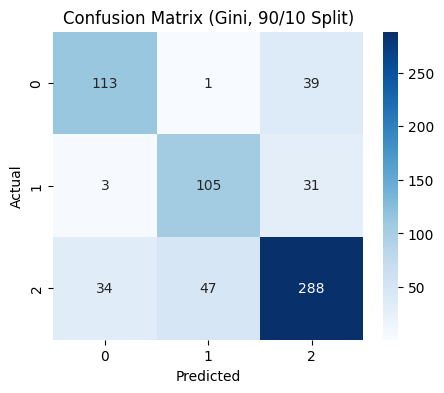

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm_90, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Gini, 90/10 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Gini  80/20 Split*

The dataset is split into 80% training and 20% testing.  
The model is trained using the Gini index and evaluated using accuracy and confusion matrix.  

The objective is to assess the models performance and its ability to correctly predict the class label using this split.

In [ ]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

gini_model_80 = DecisionTreeClassifier(criterion="gini", random_state=42)
gini_model_80.fit(X_train_80, y_train_80)

y_pred_80 = gini_model_80.predict(X_test_20)

accuracy_80 = accuracy_score(y_test_20, y_pred_80)
cm_80 = confusion_matrix(y_test_20, y_pred_80)

print("Accuracy (80/20):", accuracy_80)
print("Confusion Matrix:\n", cm_80)

Accuracy (80/20): 0.7390317700453858
Confusion Matrix:
 [[240   1  70]
 [  7 210  80]
 [ 89  98 527]]


The model achieved an accuracy of 73.9%, indicating good overall performance.  

The accuracy slightly decreased, suggesting that the model is affected by the reduction in training data.  

The confusion matrix shows that most predictions are correct, but there are still some incorrect predictions between certain classes.  

This indicates that the model sometimes struggles to clearly distinguish between similar classes.

####*Confusion Matrix 80/20*

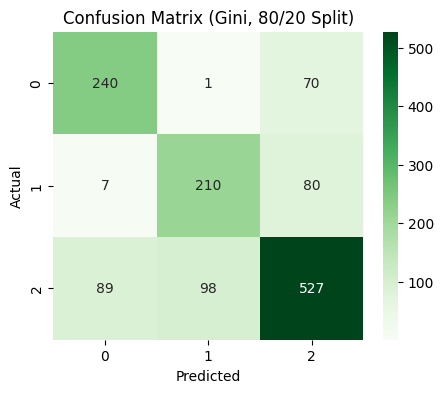

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_80, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix (Gini, 80/20 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Gini  70/30 Split*

The dataset is split into 70% training and 30% testing.  
The model is trained using the Gini index and evaluated using accuracy and confusion matrix.  

The objective is to assess the model performance and its ability to correctly predict the class label using this split.

In [ ]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.30, random_state=42
)

gini_model_70 = DecisionTreeClassifier(criterion="gini", random_state=42)
gini_model_70.fit(X_train_70, y_train_70)

y_pred_70 = gini_model_70.predict(X_test_30)

accuracy_70 = accuracy_score(y_test_30, y_pred_70)
cm_70 = confusion_matrix(y_test_30, y_pred_70)

print("Accuracy (70/30):", accuracy_70)
print("Confusion Matrix:\n", cm_70)

Accuracy (70/30): 0.7401614530776993
Confusion Matrix:
 [[345   4 114]
 [  8 316 136]
 [124 129 806]]



The model achieved an accuracy of 74.0%, indicating good overall performance.  

Compared to the previous splits, the accuracy is slightly lower, suggesting that reducing the training data has a minor impact on performance.  

The confusion matrix shows that while most predictions are correct, the model still makes some mistakes between certain classes.

#### *Confusion Matrix 70/30*

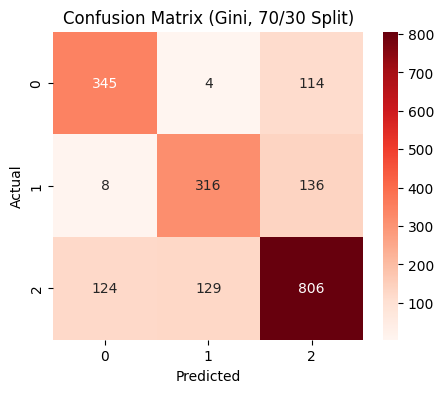

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_70, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix (Gini, 70/30 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Decision Tree Visualization Gini (90/10) Split*

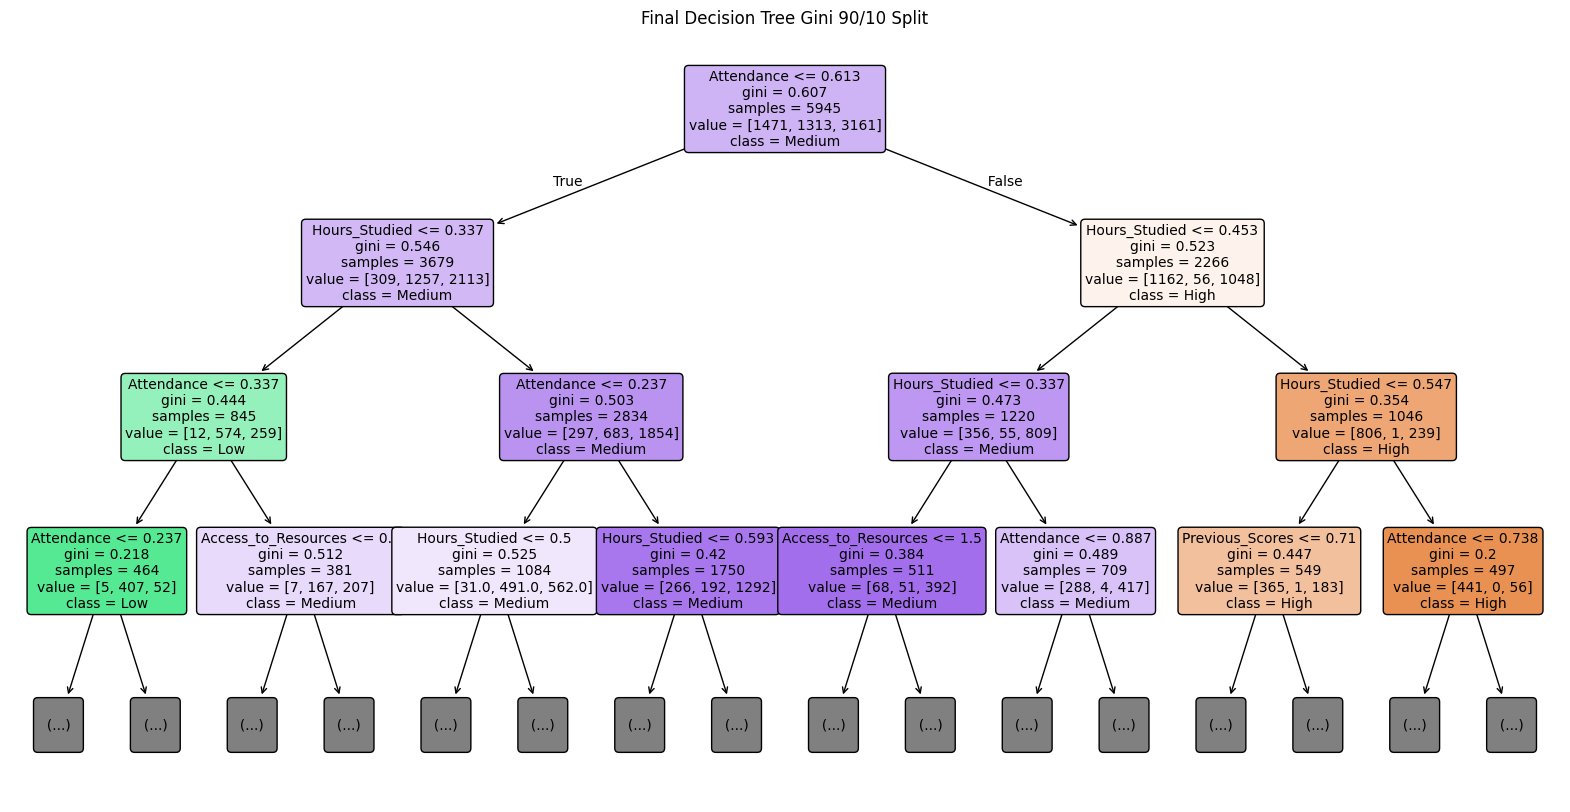

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    gini_model_90,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title("Final Decision Tree Gini 90/10 Split")
plt.show()

The decision tree shows how the model makes predictions based on different features.  

The model begins by splitting the data using the attendance feature, which indicates that it is the most important factor.  
Further splits are made based on features such as hours studied and previous scores to refine the predictions.  

This structure helps explain how the model classifies students into different performance levels.

###  *Entropy 90/10 Split*

The dataset is divided into 90% for training and 10% for testing.
A Decision Tree classifier is applied using the Entropy criterion, which is based on Information Gain.
The goal is to evaluate the model performance using accuracy and confusion matrix.

In [ ]:
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.10, random_state=42
)

# Train the model using Entropy
model_entropy_90 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_90.fit(X_train_90, y_train_90)

# Prediction
y_pred_90 = model_entropy_90.predict(X_test_10)

# Evaluation
acc_90 = accuracy_score(y_test_10, y_pred_90)
cm_90 = confusion_matrix(y_test_10, y_pred_90)

print("Accuracy:", acc_90)
print("Confusion Matrix:\n", cm_90)

Accuracy: 0.7276853252647504
Confusion Matrix:
 [[116   0  37]
 [  3  97  39]
 [ 54  47 268]]


The model achieved an accuracy of 72.77%, indicating good overall performance.
Since the training data is large, the model performs well, but there is a possibility of slight overfitting.The confusion matrix shows that most predictions are correct, with some misclassifications between classes.

#### *Confusion Matrix 90/10*

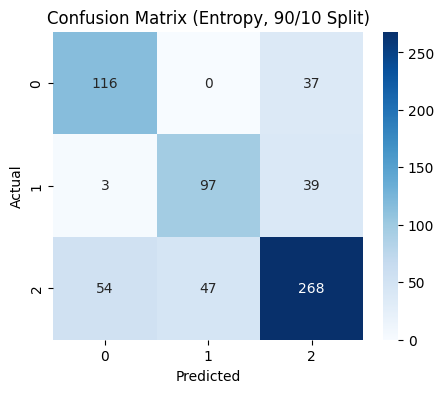

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_90, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Entropy, 90/10 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Entropy 80/20 Split*

The dataset is split into 80% training and 20% testing.
This provides a better balance between training and evaluation.

In [ ]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model_entropy_80 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_80.fit(X_train_80, y_train_80)

y_pred_80 = model_entropy_80.predict(X_test_20)

acc_80 = accuracy_score(y_test_20, y_pred_80)
cm_80 = confusion_matrix(y_test_20, y_pred_80)

print("Accuracy:", acc_80)
print("Confusion Matrix:\n", cm_80)

Accuracy: 0.7299546142208775
Confusion Matrix:
 [[222   1  88]
 [  7 218  72]
 [ 87 102 525]]


The model achieved an accuracy of 72.99%, indicating stable performance.
This split provides a better balance between training and testing data.The confusion matrix shows good classification with some errors between certain classes.

#### *Confusion Matrix 80/20*

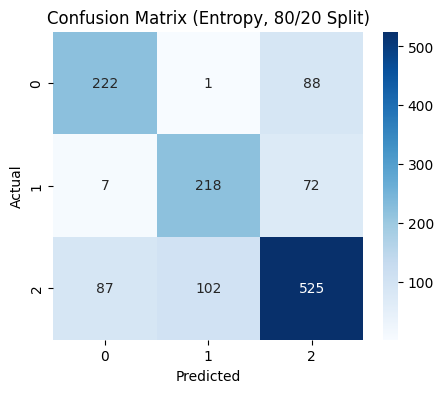

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_80, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Entropy, 80/20 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Entropy 70/30 Split*
The dataset is split into 70% training and 30% testing.
This allows a larger portion of data for testing, leading to a more realistic evaluation.

In [ ]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.30, random_state=42
)

model_entropy_70 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy_70.fit(X_train_70, y_train_70)

y_pred_70 = model_entropy_70.predict(X_test_30)

acc_70 = accuracy_score(y_test_30, y_pred_70)
cm_70 = confusion_matrix(y_test_30, y_pred_70)

print("Accuracy:", acc_70)
print("Confusion Matrix:\n", cm_70)

Accuracy: 0.7522704339051464
Confusion Matrix:
 [[341   3 119]
 [  5 332 123]
 [116 125 818]]


The model achieved an accuracy of 75.23%, indicating good overall performance.
This split provides a more realistic evaluation, as a larger portion of data is used for testing.
The confusion matrix shows that most predictions are correct, although some misclassifications still occur

#### *Confusion Matrix 70/30*

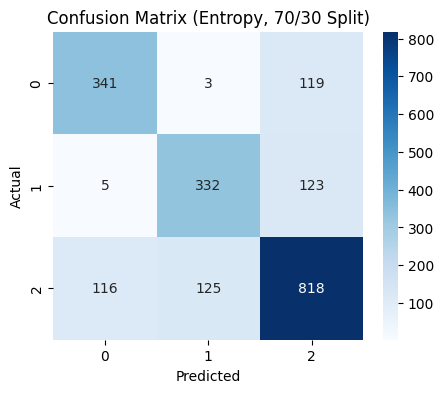

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_70, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Entropy, 70/30 Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### *Decision Tree Visualization Entropy (70/30) Split*

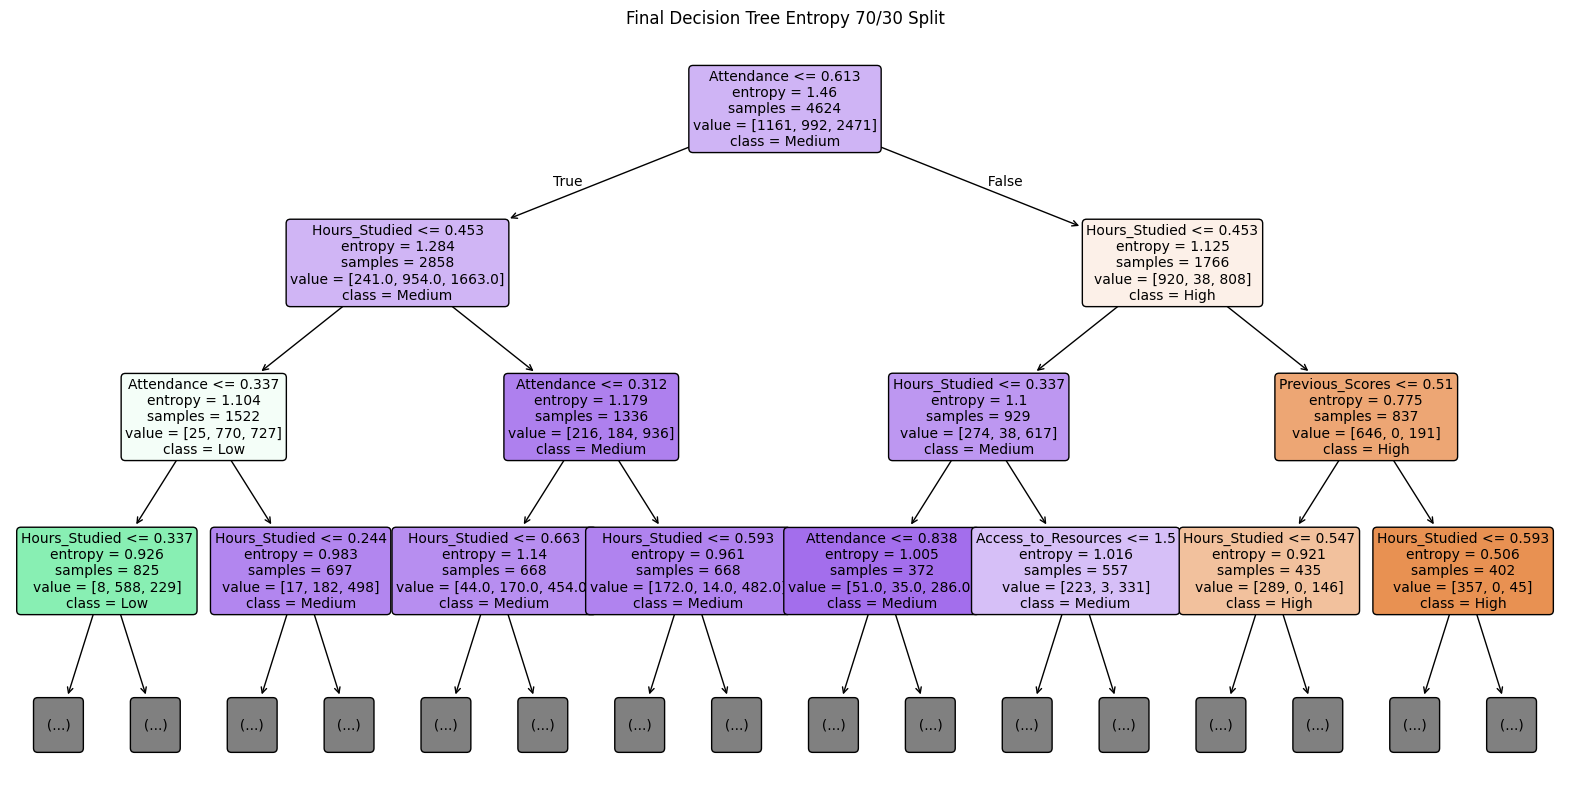

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model_entropy_70,  #
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Final Decision Tree Entropy 70/30 Split")
plt.show()

### *Gini vs Entropy Comparison*

In this section, we compare the performance of the Decision Tree classifier using both Gini and Entropy across different splits (90/10), (80/20), (70/30).

#### Confusion Matrix Comparison (Best Models)

The confusion matrices below show the performance of the best split for each criterion.

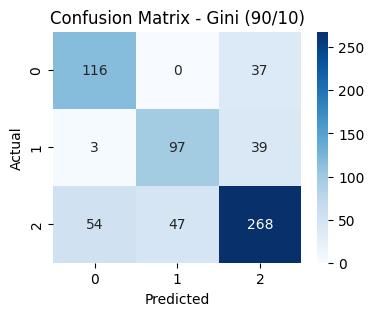

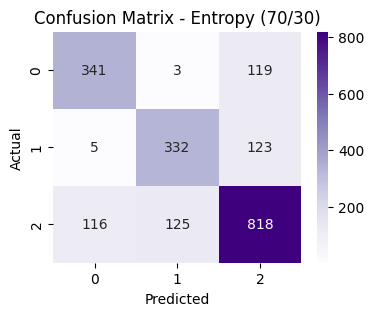

In [ ]:
# Gini (the best: 90/10)
plt.figure(figsize=(4,3))
sns.heatmap(cm_90, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gini (90/10)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Entropy (the best: 70/30)
plt.figure(figsize=(4,3))
sns.heatmap(cm_70, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Entropy (70/30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

####*Accuracy Comparison Table*

The table below compares the accuracy of Gini and Entropy across all splits.

In [ ]:
comparison_table = pd.DataFrame({
    "Split": ["90/10", "80/20", "70/30"],
    "Gini": [accuracy_90, accuracy_80, accuracy_70],
    "Entropy": [acc_90, acc_80, acc_70]
})

comparison_table

,Split,Gini,Entropy
0,90/10,0.765507,0.727685
1,80/20,0.739032,0.729955
2,70/30,0.740161,0.752270


#### *Accuracy Comparison (Bar Chart)*

This chart compares the accuracy of Gini and Entropy across different (train/test) splits.

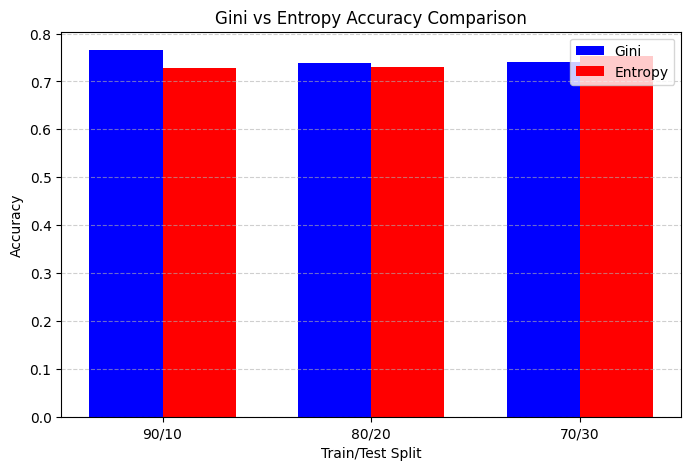

In [ ]:
import numpy as np

x = np.arange(3)
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, [accuracy_90, accuracy_80, accuracy_70], width,
        label='Gini', color="blue")

plt.bar(x + width/2, [acc_90, acc_80, acc_70], width,
        label='Entropy', color="red")

plt.xticks(x, ["90/10","80/20","70/30"])
plt.xlabel("Train/Test Split")
plt.ylabel("Accuracy")
plt.title("Gini vs Entropy Accuracy Comparison")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

###*Result Analysis*

Both Gini and Entropy show very similar performance across all splits.

For Gini, the best performance was achieved using the 90/10 split with an accuracy of 76.55%.

For Entropy, the best performance was achieved using the 70/30 split with an accuracy of 75.23%.

The differences in accuracy between the models are small, indicating that the choice of splitting criterion has a limited impact on this dataset.

Overall, Gini achieves the highest accuracy and performs best overall, while Entropy shows competitive performance in certain cases.

## *Clustering*

In this phase, clustering is performed using the K-Means algorithm.  
The goal is to group similar data points based on their features without using predefined labels.  

Different values of K are tested to determine the optimal number of clusters.  
The performance is evaluated using:

- Silhouette Score  
- Elbow Method (WCSS)  

Finally, a comparison is made to select the best value of K based on the evaluation results.

###*Import required libraries*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

###*Load the Preprocessed Dataset*

In [ ]:
url = "https://raw.githubusercontent.com/leeno-ob/IT326-project/main/Dataset/Preprocessed_dataset.csv"
df = pd.read_csv(url)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance_Level
0,0.511628,0.600,0,2,0,0.500000,0.46,0,1,0,0,1,1,2,3,0,0,0,0,Medium
1,0.418605,0.100,0,1,0,0.666667,0.18,0,1,2,1,1,1,0,4,0,1,1,1,Low
2,0.534884,0.950,1,1,1,0.500000,0.82,1,1,2,1,1,1,1,4,0,2,0,0,High
3,0.651163,0.725,0,1,1,0.666667,0.96,1,1,1,1,1,1,0,4,0,0,1,0,High
4,0.418605,0.800,1,1,1,0.333333,0.30,1,1,3,1,2,1,1,4,0,1,0,1,High


### *Prepare Data for Clustering*
Preparing the  dataset for clustering by removing class label (Performance_Level), then scale it using StandardScaler.

In [ ]:
# Drop class label for clustering
X = df.drop(columns=['Performance_Level'])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X_scaled:", X_scaled.shape)


Shape of X_scaled: (6606, 19)


### *Choosing the Best K*

To determine the optimal number of clusters, we tested different values of K and evaluated them using:
- Silhouette Score
- Total within-cluster sum of squares (WCSS)

These methods help identify the most suitable number of clusters.

In [ ]:
k_values = range(2, 6)
silhouette_scores = []
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    silhouette_scores.append(silhouette_score(X_scaled, labels))
    wcss.append(kmeans.inertia_)

    print(f"K = {k}")
    print(f"Silhouette Score = {silhouette_score(X_scaled, labels):.4f}")
    print(f"WCSS = {kmeans.inertia_:.4f}")
    print("-" * 30)

K = 2
Silhouette Score = 0.0566
WCSS = 118896.4765
------------------------------
K = 3
Silhouette Score = 0.0405
WCSS = 115678.0272
------------------------------
K = 4
Silhouette Score = 0.0424
WCSS = 112066.6958
------------------------------
K = 5
Silhouette Score = 0.0461
WCSS = 107216.3859
------------------------------


### *Silhouette Score for Different K*
The Silhouette Score is a method used to measure the clustering quality and determine the optimal number of clusters.

A higher Silhouette Score indicates better separation between clusters and more clearly defined groups.

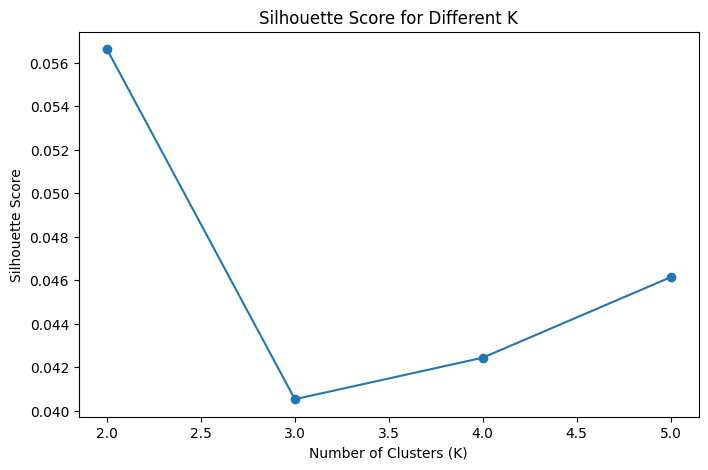

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()


### *Silhouette Score Results*



The Silhouette Score was calculated for different values of K (from 2 to 5).

From the graph, the highest Silhouette Score was shown at K = 2, which indicates that this value provides the best separation between clusters.

When K increased after 2, the Silhouette Score decreased, indicating that the clustering became less effective.

Therefore, K = 2 is considered the optimal number of clusters based on the Silhouette Score.

### *Elbow Method for Optimal K*

The Elbow Method is used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS).

The goal is to find the point where the decrease in WCSS slows down, forming an "elbow" shape in the graph.

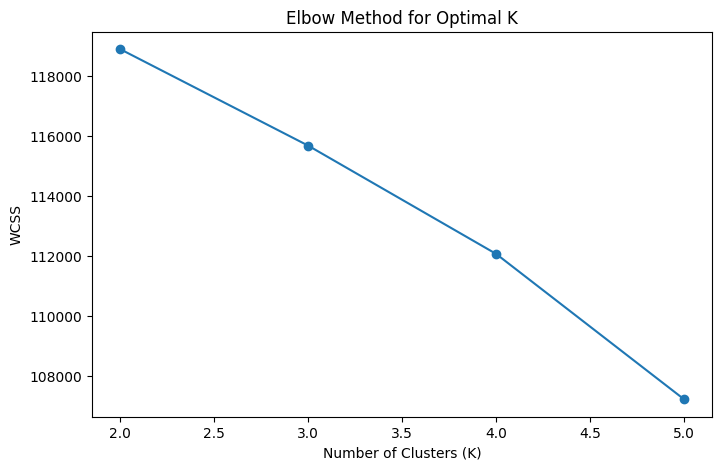

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

### *Elbow Method – Results*

From the graph, the elbow point appears at K = 2, where the decrease in WCSS starts to slow down.

This indicates that adding more clusters beyond this point does not significantly improve clustering.

Therefore, K = 2 is selected as the optimal number of clusters using the Elbow Method.

This section determines the optimal number of clusters (K) by comparing the results of the Silhouette Score and the Elbow Method.

In [ ]:
# Select the best K based on majority rule

best_k_silhouette = list(k_values)[silhouette_scores.index(max(silhouette_scores))]

# Best K from elbow method is selected by observing the bending point in the WCSS plot
best_k_elbow = 2   # replace it with the elbow point observed from your plot

print("Best K based on Silhouette Score:", best_k_silhouette)
print("Best K based on Elbow Method:", best_k_elbow)

if best_k_silhouette == best_k_elbow:
    best_k = best_k_silhouette
else:
    best_k = best_k_silhouette   # choose the repeated/most supported K

print("Best K based on majority rule:", best_k)

Best K based on Silhouette Score: 2
Best K based on Elbow Method: 2
Best K based on majority rule: 2


### *Best K – Result*

Based on the results from both the Silhouette Score and the Elbow Method, the optimal number of clusters is K = 2.

Both methods consistently indicate that K = 2 provides the best clustering performance.

Therefore, K = 2 is selected as the final optimal number of clusters.

This section visualizes the clustering results for each value of K to better understand the formed groups and the separation between clusters.

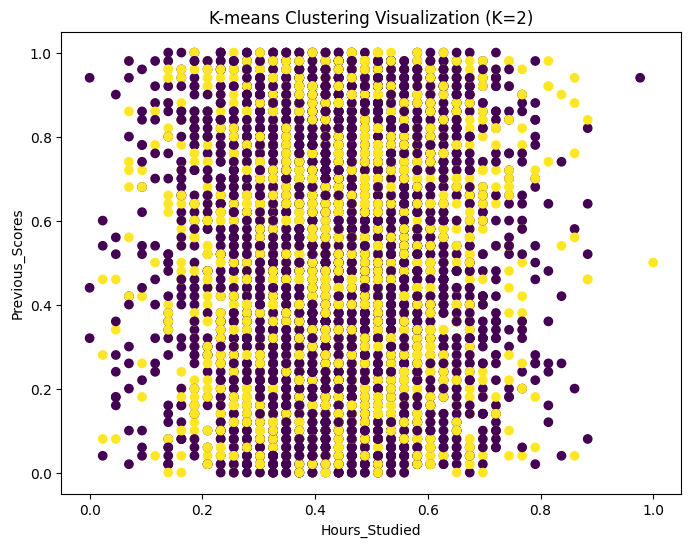

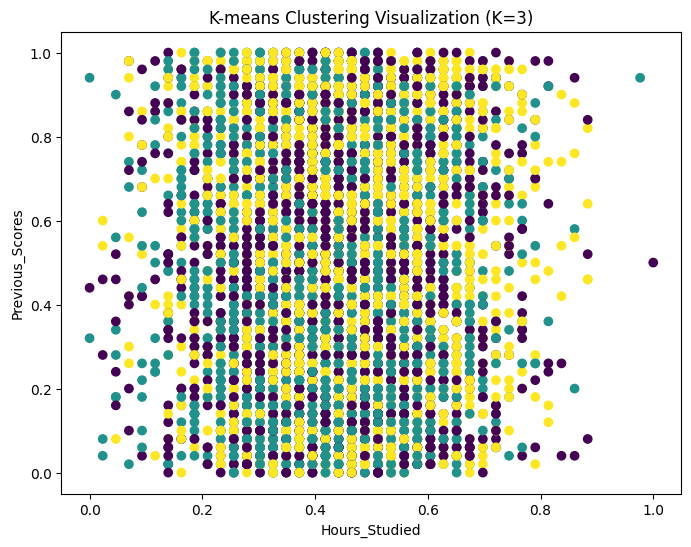

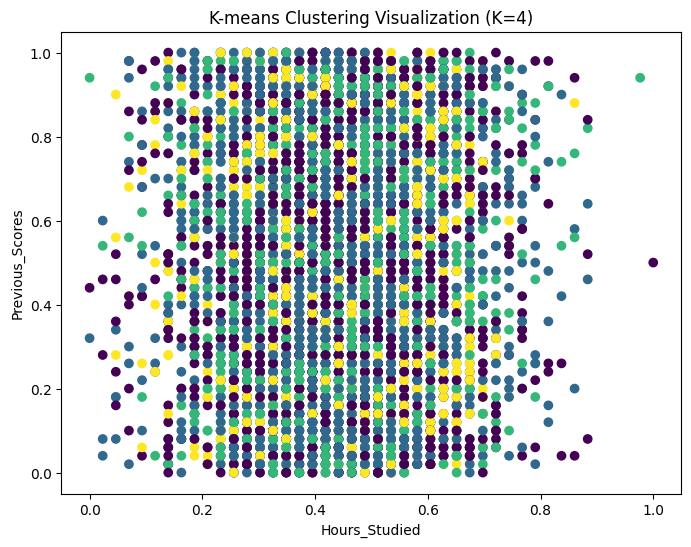

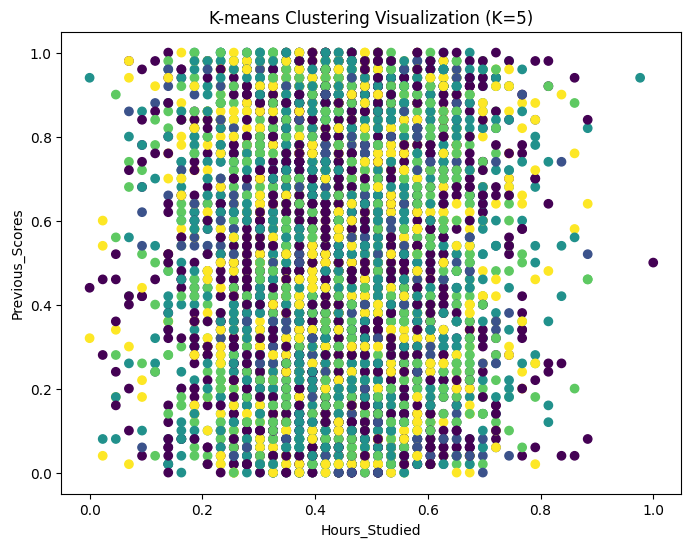

In [ ]:
# Cluster visualization for each K

selected_columns = ["Hours_Studied", "Previous_Scores"]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_k = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(df[selected_columns[0]], df[selected_columns[1]], c=labels_k)
    plt.xlabel(selected_columns[0])
    plt.ylabel(selected_columns[1])
    plt.title(f"K-means Clustering Visualization (K={k})")
    plt.show()

From the figures, the clustering results vary across different values of K.

For K = 2, the data is divided into two main groups, showing general separation but with some overlap.

As K increases (K = 3, 4, and 5), the clusters become more scattered and less clearly defined.

This indicates that increasing the number of clusters does not necessarily improve the clustering quality.

Overall, K = 2 provides the most meaningful and interpretable grouping of the data.

### *Clustering Evaluation Table*

The following table summarizes the clustering results for each tested value of K, including:
- Silhouette Score
- WCSS

This helps in comparing the clustering quality and selecting the optimal number of clusters.


In [ ]:
results_df = pd.DataFrame({
    'K': list(k_values),
    'Silhouette Score': silhouette_scores,
    'WCSS': wcss
})

results_df

,K,Silhouette Score,WCSS
0,2,0.056622,118896.476488
1,3,0.040522,115678.027229
2,4,0.042431,112066.695787
3,5,0.046134,107216.385882


From the table, the highest Silhouette Score is observed at K = 2.

As K increases, the WCSS decreases.

This confirms that K = 2 is the optimal number of clusters.

### *Final Clustering Visualization*

This section visualizes the clustering results using the selected optimal number of clusters (K).

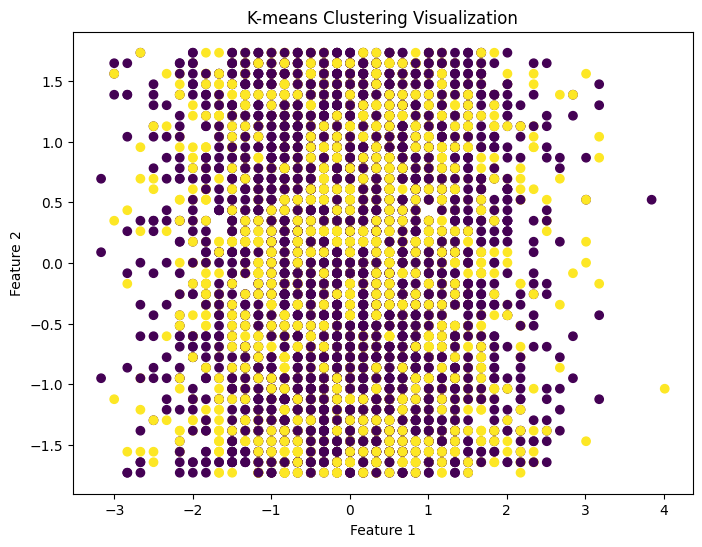

In [ ]:
# Final clustering visualization using the selected best K

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(df[selected_columns[0]], df[selected_columns[1]], c=labels)
plt.xlabel(selected_columns[0])
plt.ylabel(selected_columns[1])
plt.title(f"K-means Clustering Results (Best K = {best_k})")
plt.show()

### *Clustering Visualization – Interpretation*

The plot shows the clustering result for the selected best K.  
Each color represents one cluster formed by the K-means algorithm.  
The visualization helps in understanding the similarity between records and the separation between the clusters based on the selected attributes.

### *Clustering Findings*

K-means clustering was applied using three different values of K.  
The clustering results were evaluated using the Silhouette Score and the Elbow Method based on WCSS.  

For each value of K, the clustering result was visualized and interpreted.  
The optimal number of clusters was selected based on the majority rule.  

The final clustering result shows that the dataset can be grouped into meaningful clusters based on similarity among the records.

# **7-FINDINGS AND DISCUSSION**
This section summarizes the results obtained by applying classification and clustering techniques on the dataset.

**Classification Findings:** For classification, multiple models were evaluated based on their accuracy. The results showed that one model outperformed the others in predicting student performance, showing that classification techniques can effectively help in educational decision-making.



**Clustering Findings:** For clustering, K-means was applied with different values of K. The performance was evaluated using the Silhouette Score and the Elbow Method, both of which indicated that K = 2 is the optimal number of clusters.

The clustering results indicate that students can be grouped into two primary clusters based on their performance. These clusters represent different levels of student achievement, although there is some overlap between them.




In terms of evaluation, classification provides predictive capability by assigning students to performance categories, while clustering provides descriptive insights by revealing patterns in the data. The moderate classification accuracy indicates that student performance is affected by multiple overlapping factors. The visualization of clusters confirms the presence of natural groupings among students. Overall, the findings from both classification and clustering are significant and provide valuable insights into student performance. These insights can help identify students who may need additional support and improve teaching strategies.

The findings support previous research [1], [2], confirming that clustering and classification techniques are effective tools for analyzing student performance data.




# **8-REFERENCES**
[1] R. Asif, A. Merceron, S. A. Ali, and N. G. Haider, “Analyzing undergraduate students' performance using educational data mining,” Computers & Education, vol. 113, pp. 177–194, 2017. Available: https://doi.org/10.1016/j.compedu.2017.05.007

[2] S. M. Alrashdi and A. Zeki, “Analyzing the factors that influence enhancing student performance in Oman using data mining,” Journal of Science and Technology, vol. 27, no. 1, 2022.

[3] F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” Journal of Machine Learning Research, vol. 12, pp. 2825–2830, 2011. Available: https://jmlr.org/papers/volume12/pedregosa11a/pedregosa11a.pdf